In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
import kmodes
from kmodes.kprototypes import KPrototypes
import time

In [2]:
df = pd.read_parquet('montgomery_crash_reporting_processed.parquet', engine='pyarrow')

In [3]:
df.head()

,agency_name,acrs_report_type,hit_run,route_type,distance,at_fault,collision_type,weather,surface_condition,light,...,road_alignment_Other,road_alignment_Straight,road_alignment_cat,road_division_cat,is_two_way,division,division_type,left_turn,road_grade_Not_Relevant,road_alignment_Not_Relevant
0,Montgomery County Police,Injury Crash,0,Highway,0.002945,Driver,Single Vehicle,Clear,Dry,Dark Lighted,...,0,1,Straight,"Two-Way, Divided, Raised Median, Nan",1,Divided,Raised Median,NaN,0,0
1,Gaithersburg Police Depart,Property Damage Crash,0,Highway,0.000000,Driver,Same Dir Rear End,Clear,Dry,Dark Lighted,...,0,1,Straight,"Two-Way, Not Divided, Not Relevant, Nan",1,Not Divided,Not Relevant,NaN,0,0
2,Montgomery County Police,Property Damage Crash,0,Highway,0.002114,NaN,Single Vehicle,Clear,Dry,Dark,...,0,1,Straight,"Two-Way, Not Divided, Not Relevant, Nan",1,Not Divided,Not Relevant,NaN,0,0
3,Gaithersburg Police Depart,Property Damage Crash,0,Ramp/ Spur,0.002843,Driver,Same Dir Rear End,Clear,Dry,Dark Lighted,...,0,1,Straight,"Two-Way, Not Divided, Not Relevant, Nan",1,Not Divided,Not Relevant,NaN,0,0
4,Gaithersburg Police Depart,Property Damage Crash,0,Local,0.005068,Driver,Same Dir Rear End,Clear,Dry,Dark Lighted,...,0,1,Straight,"Two-Way, Divided, Raised Median, Nan",1,Divided,Raised Median,NaN,0,0


1. למלא ערכים חסרים לגמרי (נומרי סטטיסטיקות, קטגוריאלי שכיח או unknown

2. נרמול לעמודות הנומריות - StandardScaler

3. צריך להגיד למודל אילו אינדקסים נומריים ואילו קטגוריאליים (מותר לעשות סולם סדר, אבל אסור לעשות קידוד אחר!! הוא בנוי לקבל קטגוריה)

4. אין פייפליין מובנה 

5. אין דאטה ליקיג קלאסי כי אין חיזוי, אבל יש סכנה של זיהום המטרה. לדוגמה אם נכניס את חומרת התאונה זה יעשה קיבוץ קלאסי לפי חומרה ואנחנו מעוניינים לחפש לדוגמה תובנות מעניינות על התשתית, ולכן לא נכניס את זה.

6. הזרימה: בחירת העמודות הרלוונטיות (בלי קורדינאטות, בלי עמודת מטרה?), אימפיוט, חלוקה בין נומרי לקטגוריאלי, נירמול הנומריים ואיחוד בחזרה, שמירת האינדקסים - להגיד למודל מי קטגוריאלי, הרצת לולאה למציאת K אופטימלי, אימון המודל

## Pipeline

In [4]:
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Data_Type': [df[col].dtype for col in df.columns]
})
feature_summary

,Feature,Unique_Values,Data_Type
0,agency_name,6,category
1,acrs_report_type,3,category
2,hit_run,2,Int64
3,route_type,5,category
4,distance,5834,float64
5,at_fault,3,category
6,collision_type,6,category
7,weather,7,category
8,surface_condition,4,category
9,light,6,category


In [5]:
# 1) עמודות קטגוריאליות
categorical_columns = [
    'route_type', 'weather', 'light', 
    'junction', 'road_condition', 'surface_condition',
    'season', 'road_grade_cat', 'road_division_cat', 
    'traffic_control', 'road_alignment_cat', 'division_type', 'time_of_day',
    'left_turn', 'division', 'first_harmful_event', 'second_harmful_event', 
    'at_fault', 'collision_type', 'num_directions', 'lane_category', 'agency_name',
    'is_two_way', 'road_grade_Downhill', 'road_grade_Hillcrest', 'road_grade_Level', 
    'road_grade_On_Bridge', 'road_grade_Other', 'road_grade_Sag', 
    'road_grade_Uphill', 'road_alignment_Curve_Left', 'road_alignment_Curve_Right', 
    'road_alignment_Other', 'road_alignment_Straight', 
    'road_alignment_Not_Relevant', 'road_grade_Not_Relevant',
    'is_weekend', 'is_holiday', 'driver_substance_abuse', 'hit_run' 
]

# 2) עמודות מספריות
numeric_columns = ['distance', 'crash_year', 'hour', 'month', 'day_of_week']

### Categorical Columns

In [6]:
# --- המרה לסטרינג ומילוי ערכים חסרים---
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)
        
        df[col] = df[col].replace(
            ['nan', 'NaN', '<NA>', 'None', 'Nat'], 'Unknown')

### Numeric Columns

מתוך ההנחה הבאה:
ממש בצומת (0.0)

התקרבות לצומת (0.1)

כביש פתוח (0.5 - 2.0)

עשינו קיטום למרחק ב2

In [7]:
# --- קיטום ---
# אנחנו מתעלמים מה-IQR המחמיר (0.02) לטובת היגיון עסקי (2.0)
# כדי לאפשר למודל להבדיל בין תאונות צומת לתאונות דרך.
df['distance'] = df['distance'].clip(upper=2.0)
# --- השלמת חסרים ---
df['distance'] = df['distance'].fillna(df['distance'].median())

# --- נירמול ---
df_model = df[numeric_columns + categorical_columns].copy()
scaler = StandardScaler()
df_model[numeric_columns] = scaler.fit_transform(df_model[numeric_columns])

### Model

In [9]:
data_matrix = df_model.to_numpy()

In [10]:
cat_columns_indices = [df_model.columns.get_loc(col) for col in categorical_columns]

--- Starting Elbow Method ---
Running for k=2...
Running for k=3...
Running for k=4...
Running for k=5...
Running for k=6...
Running for k=7...

Done! Total time: 14.23 minutes.


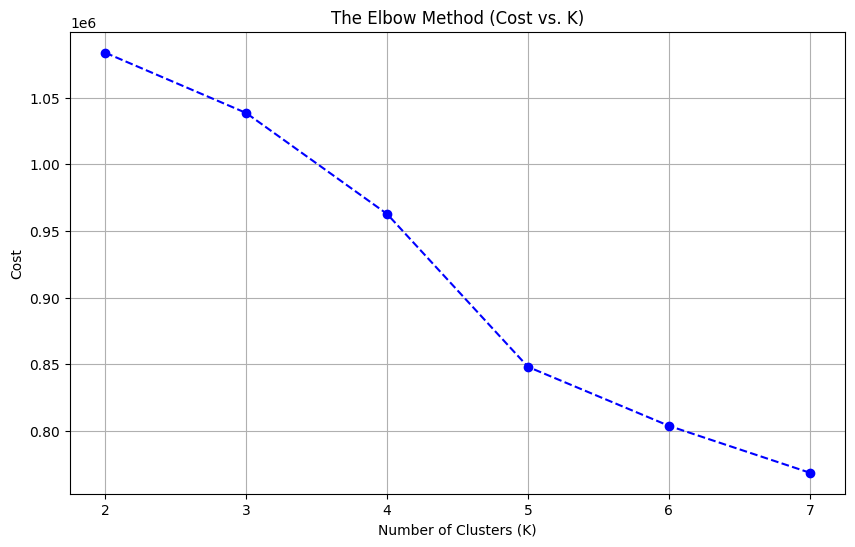

K=2: 1083577.47
K=3: 1038396.72
K=4: 962691.33
K=5: 848048.69
K=6: 803839.48
K=7: 768674.35


In [12]:
# טווח הקלאסטרים שנבדוק (למשל מ-2 עד 7)
# אם הדאטה ענק והמחשב איטי, אפשר להקטין את הטווח או לדגום חלק מהשורות
k_range = range(2, 8)
costs = []

print("--- Starting Elbow Method ---")
start_time = time.time()

for k in k_range:
    print(f"Running for k={k}...")
    
    # הגדרת המודל
    # init='Cao': שיטת אתחול מהירה וטובה ל-K-Prototypes
    # n_init=1: מריץ פעם אחת לכל K (כדי לחסוך זמן בשלב הבדיקה)
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, n_init=1)
    
    # אימון המודל
    # חשוב מאוד: מעבירים את המטריצה ואת רשימת האינדקסים הקטגוריאליים
    kproto.fit(data_matrix, categorical=cat_columns_indices)
    
    # שמירת ה-Cost (המחיר/השגיאה)
    costs.append(kproto.cost_)

print(f"\nDone! Total time: {round((time.time() - start_time)/60, 2)} minutes.")

# --- שלב 2: ציור הגרף ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, costs, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method (Cost vs. K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# הדפסת הערכים כדי לראות את הירידה במספרים
for k, cost in zip(k_range, costs):
    print(f"K={k}: {cost:.2f}")